## Test a New Strategy

In [2]:
%load_ext autoreload
%autoreload 2
import logging
from qrt.data import *
from qrt.utils import *
from qrt.constants import *
from qrt.qrt_utils import *
from qrt.strategies import *

logging.basicConfig(level=logging.WARNING, format='%(asctime)s | %(levelname)s | %(message)s', force=True)

In [24]:
update_price_data()

### Raw Data

In [3]:
historical_bb = pd.read_parquet(PRICE_DIR / BB_HISTORICAL)
active_lseg = pd.read_parquet(PRICE_DIR / LSEG_ACTIVE)

### Active Constituents Data

In [4]:
active_prices_rua, active_vol_rua = get_timeseries(active_lseg, stock_index=RUA), get_timeseries(active_lseg, value='Volume', stock_index=RUA)
active_eligible_rua = eligible_to_trade(active_prices_rua, active_vol_rua, stock_index=RUA)
active_returns_rua = active_prices_rua.ffill(limit=2).pct_change(fill_method=None).iloc[1:]

active_prices_stoxx, active_vol_stoxx = get_timeseries(active_lseg, stock_index=STOXX), get_timeseries(active_lseg, value='Volume', stock_index=STOXX)
active_eligible_stoxx = eligible_to_trade(active_prices_stoxx, active_vol_stoxx, stock_index=STOXX)
active_returns_stoxx = active_prices_stoxx.ffill(limit=2).pct_change(fill_method=None).iloc[1:]

### Historical Constituents Data

In [4]:
hist_prices_rua, hist_vol_rua = get_timeseries(historical_bb, stock_index=RUA, data_type='historical'), get_timeseries(historical_bb, value='Volume', stock_index=RUA, data_type='historical')
hist_eligible_rua = eligible_to_trade(hist_prices_rua, hist_vol_rua, stock_index=RUA)
hist_returns_rua = hist_prices_rua.ffill(limit=2).pct_change(fill_method=None).iloc[1:]

hist_prices_stoxx, hist_vol_stoxx = get_timeseries(historical_bb, stock_index=STOXX, data_type='historical'), get_timeseries(historical_bb, value='Volume', stock_index=STOXX, data_type='historical')
hist_eligible_stoxx = eligible_to_trade(hist_prices_stoxx, hist_vol_stoxx, stock_index=STOXX)
hist_returns_stoxx = hist_prices_stoxx.ffill(limit=2).pct_change(fill_method=None).iloc[1:]

KeyboardInterrupt: 

### Fundamental Data

In [5]:
active_sectors = get_data(active_lseg.RIC.unique().tolist(), ['TR.GICSSector'])
# historical_sectors = get_data(historical_bb.ISIN.unique().tolist(), ['TR.GICSSector'])

In [6]:
active_lseg_fund = pd.read_parquet(FUNDAMENTALS_DIR / LSEG_ACTIVE)
active_fundamentals = {}
for col in active_lseg_fund.columns[:-1]:
    key = col.lower().replace(' - actual', '').replace(' ', '_')
    pivoted = active_lseg_fund.pivot_table(index=active_lseg_fund.index, columns='RIC', values=col, observed=False)
    pivoted = pivoted.sort_index()
    active_fundamentals[key] = pivoted.ffill()

# historical_bb_fund = pd.read_parquet(FUNDAMENTALS_DIR / BB_HISTORICAL)
# historical_fundamentals = {}
# for col in historical_bb_fund.columns[:-1]:
#     key = col.lower().replace(' - actual', '').replace(' ', '_')
#     pivoted = historical_bb_fund.pivot_table(index=historical_bb_fund.index, columns='ISIN', values=col, observed=False)
#     pivoted = pivoted.sort_index()
#     historical_fundamentals[key] = pivoted.ffill()

### 1. Run strategies with active stock returns

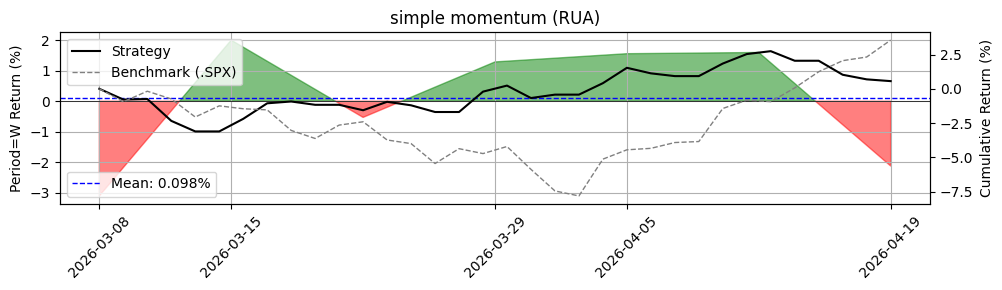

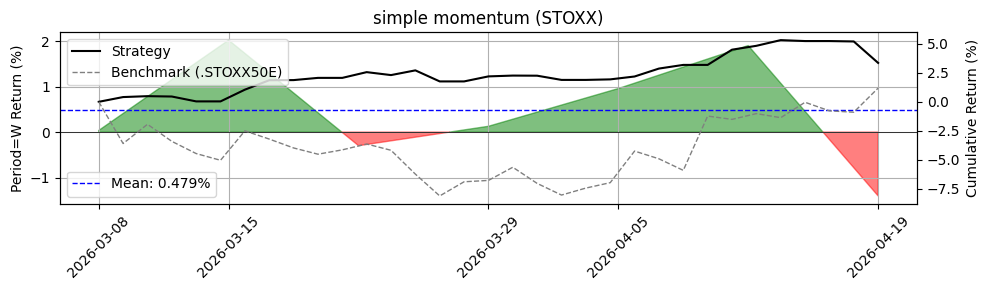

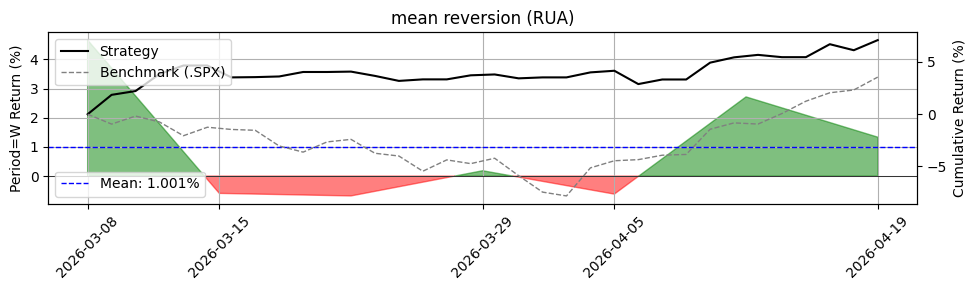

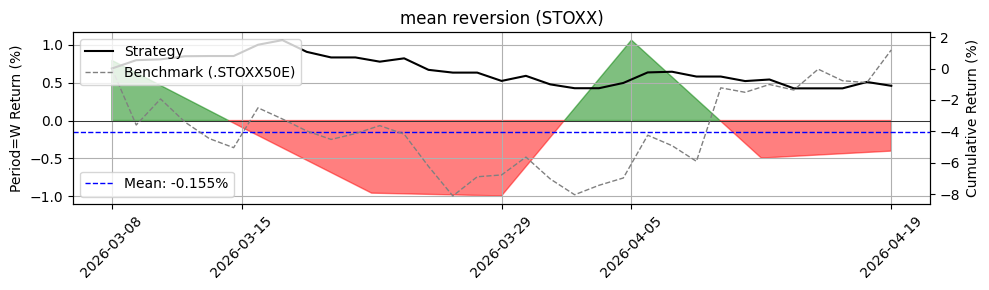

Running 3 reb_dates
Completed 3 all_weights


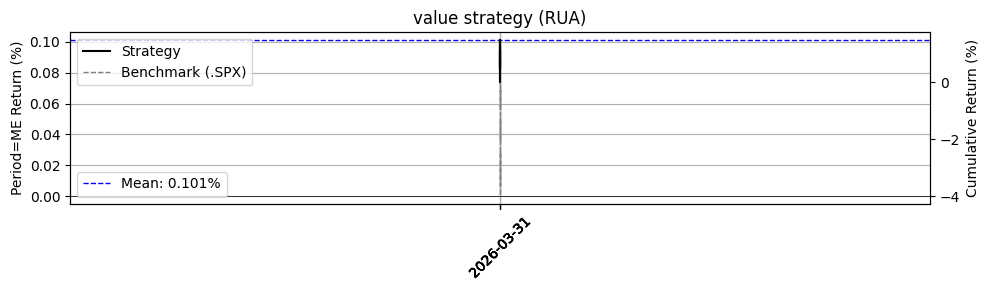

Running 3 reb_dates
Completed 3 all_weights


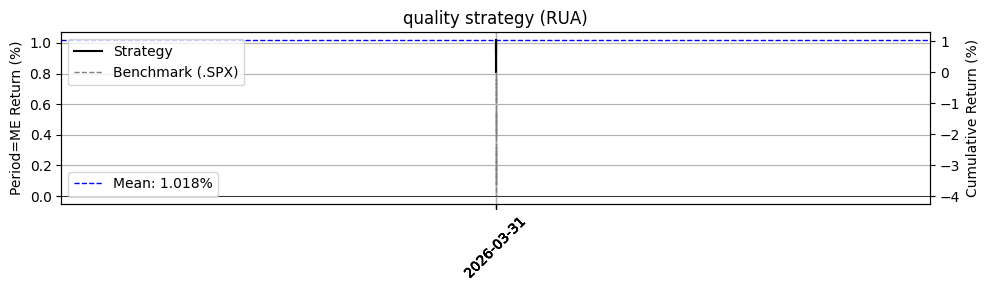

In [86]:
competition_start = '2026-03-01'

# # TIT MOM: RUA
# daily_ret, summary = backtest(
#     strategy_fn=titman_min_var_momentum,
#     return_data=active_returns_rua, 
#     volume_eligible=active_eligible_rua,
#     stock_index=RUA,
#     start_date=competition_start,
#     end_date=str(datetime.now().date()),
#     rebalance_freq=5,
#     # strategy_fn args:
#     lookback=252,
#     skip_last=21,
#     mom_quantile_top=0.8, 
#     mom_quantile_bottom=0.2, 
#     apply_screener=True, 
#     display_screener=False
# )
# # TIT MOM: STOXX
# daily_ret, summary = backtest(
#     strategy_fn=titman_min_var_momentum,
#     return_data=active_returns_stoxx, 
#     volume_eligible=active_eligible_stoxx,
#     stock_index=STOXX,
#     start_date=competition_start,
#     end_date=str(datetime.now().date()),
#     rebalance_freq=5,
#     # strategy_fn args:
#     lookback=252,
#     skip_last=21,
#     mom_quantile_top=0.8, 
#     mom_quantile_bottom=0.1, 
#     apply_screener=True, 
#     display_screener=False
# )

# SIM MOM: RUA
daily_ret, summary = backtest(
    strategy_fn=simple_momentum,
    return_data=active_returns_rua, 
    volume_eligible=active_eligible_rua,
    stock_index=RUA,
    start_date=competition_start,
    end_date=str(datetime.now().date()),
    rebalance_freq=5,
    # strategy_fn args:
    lookback=252, skip_last=10, quantile_top=0.8, quantile_bottom=0.2, vol_quantile=0.3
)
# SIM MOM: STOXX
daily_ret, summary = backtest(
    strategy_fn=simple_momentum,
    return_data=active_returns_stoxx, 
    volume_eligible=active_eligible_stoxx,
    stock_index=STOXX,
    start_date=competition_start,
    end_date=str(datetime.now().date()),
    rebalance_freq=5,
    # strategy_fn args:
    lookback=252, skip_last=10, quantile_top=0.8, quantile_bottom=0.2, vol_quantile=0.3
)

# MEAN REVERT: RUA
daily_ret, summary = backtest(
    strategy_fn=mean_reversion,
    return_data=active_returns_rua, 
    volume_eligible=active_eligible_rua,
    stock_index=RUA,
    start_date=competition_start,
    end_date=str(datetime.now().date()),
    rebalance_freq=5,
    # strategy_fn args:
    lookback=20,
    skip=5,
    quantile_top = 0.90,
    quantile_bottom = 0.10,
    vol_quantile = 0.95
)
# MEAN REVERT: STOXX
daily_ret, summary = backtest(
    strategy_fn=mean_reversion,
    return_data=active_returns_stoxx, 
    volume_eligible=active_eligible_stoxx,
    stock_index=STOXX,
    start_date=competition_start,
    end_date=str(datetime.now().date()),
    rebalance_freq=5,
    # strategy_fn args:
    lookback=5,
    skip=0,
    quantile_top = 0.90,
    quantile_bottom = 0.10,
    vol_quantile = 0.95
)

# VALUE: RUA
daily_ret, summary = backtest(
    strategy_fn=value_strategy,
    return_data=active_returns_rua, 
    volume_eligible=active_eligible_rua,
    stock_index=RUA,
    start_date=competition_start,
    end_date='2026-03-20',
    rebalance_freq=5,
    resample='ME',
    # strategy_fn args:
    fundamentals=active_fundamentals
)

# QUALITY: RUA
daily_ret, summary = backtest(
    strategy_fn=quality_strategy,
    return_data=active_returns_rua, 
    volume_eligible=active_eligible_rua,
    stock_index=RUA,
    start_date=competition_start,
    end_date='2026-03-20',
    rebalance_freq=5,
    resample='ME',
    # strategy_fn args:
    fundamentals=active_fundamentals
)


### 2. Backtest with historical returns

In [ ]:
hist_backtest_start = '2020-03-20'
# TIT MOM: RUA
daily_ret, summary = backtest(
    strategy_fn=titman_min_var_momentum,
    return_data=hist_returns_rua, 
    volume_eligible=hist_eligible_rua,
    stock_index=RUA,
    start_date=hist_backtest_start,
    end_date='2026-03-20',
    rebalance_freq=5,
    parallel=True,
    # strategy_fn args:
    mom_quantile_top=0.8, mom_quantile_bottom=0.2,
)
# TIT MOM: STOXX
daily_ret, summary = backtest(
    strategy_fn=titman_min_var_momentum,
    return_data=hist_returns_stoxx, 
    volume_eligible=hist_eligible_stoxx,
    stock_index=STOXX,
    start_date=hist_backtest_start,
    end_date='2026-03-20',
    rebalance_freq=5,
    parallel=True,
    # strategy_fn args:
    mom_quantile_top=0.8, mom_quantile_bottom=0.2,
)

# SIM MOM: RUA
daily_ret, summary = backtest(
    strategy_fn=simple_momentum,
    return_data=hist_returns_rua, 
    volume_eligible=hist_eligible_rua,
    stock_index=RUA,
    start_date=hist_backtest_start,
    end_date='2026-03-20',
    rebalance_freq=5,
    resample='ME',
    # strategy_fn args:
)
# SIM MOM: STOXX
daily_ret, summary = backtest(
    strategy_fn=simple_momentum,
    return_data=hist_returns_stoxx, 
    volume_eligible=hist_eligible_stoxx,
    stock_index=STOXX,
    start_date=hist_backtest_start,
    end_date='2026-03-20',
    rebalance_freq=5,
    resample='ME',
    # strategy_fn args:
)

# VALUE: RUA
daily_ret, summary = backtest(
    strategy_fn=value_strategy,
    return_data=hist_returns_rua, 
    volume_eligible=hist_eligible_rua,
    stock_index=RUA,
    start_date=hist_backtest_start,
    end_date='2026-03-20',
    rebalance_freq=5,
    resample='ME',
    # strategy_fn args:
    fundamentals=historical_fundamentals
)
# VALUE: STOXX
daily_ret, summary = backtest(
    strategy_fn=value_strategy,
    return_data=hist_returns_stoxx, 
    volume_eligible=hist_eligible_stoxx,
    stock_index=STOXX,
    start_date=hist_backtest_start,
    end_date='2026-03-20',
    rebalance_freq=5,
    resample='ME',
    # strategy_fn args:
    fundamentals=historical_fundamentals
)

# QUALITY: RUA
daily_ret, summary = backtest(
    strategy_fn=quality_strategy,
    return_data=hist_returns_rua, 
    volume_eligible=hist_eligible_rua,
    stock_index=RUA,
    start_date=hist_backtest_start,
    end_date='2026-03-20',
    rebalance_freq=5,
    resample='ME',
    # strategy_fn args:
    fundamentals=historical_fundamentals
)
# QUALITY: STOXX
daily_ret, summary = backtest(
    strategy_fn=quality_strategy,
    return_data=hist_returns_stoxx, 
    volume_eligible=hist_eligible_stoxx,
    stock_index=STOXX,
    start_date=hist_backtest_start,
    end_date='2026-03-20',
    rebalance_freq=5,
    resample='ME',
    # strategy_fn args:
    fundamentals=historical_fundamentals
)


NameError: name 'hist_returns_rua' is not defined

### 3. Combine RUA & Stoxx porfolios, and scale risk to 500k USD

{'Portfolio Start': '2026-04-21 00:00:00', 'In-Sample Return': '248.15%', 'In-Sample Vol': '19.18%', 'In-Sample Sharpe': '12.94', 'Beta (single-name, raw)': '0.228', 'Beta (total, shrunk)': '0.000', 'Benchmark hedge wt': '-0.058', 'Positions': 52, 'Longs': 29, 'Shorts': 23, 'Gross Leverage': '2.05x'}


Market Value           4,129,260
Combined Risk (USD)      500,000
AMER Risk                500,000
dtype: object

### 4. Plot Recent Performance & Submit Positions to QRT

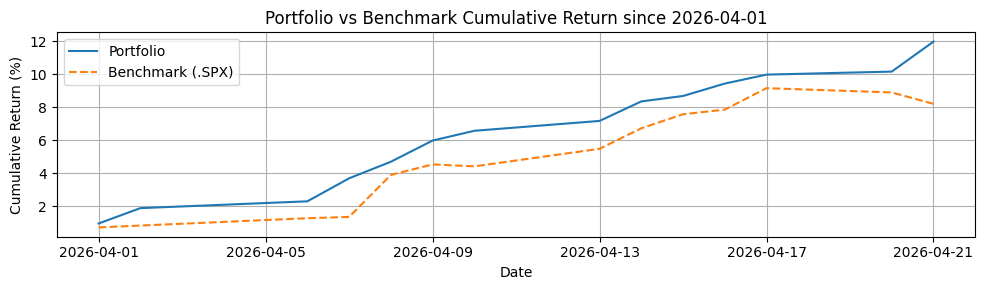

500000.00613283546
Found 0 error(s) while validating /Users/dcunning/Code/Python/imperial/QRT/target_files/AMER/qrt_academy_ICL05_20260422-1953.csv
beta: 0.0659419831235604
Found 0 error(s) while validating /Users/dcunning/Code/Python/imperial/QRT/target_files/EMEA/qrt_academy_ICL05_20260422-1953.csv
beta: 0.0


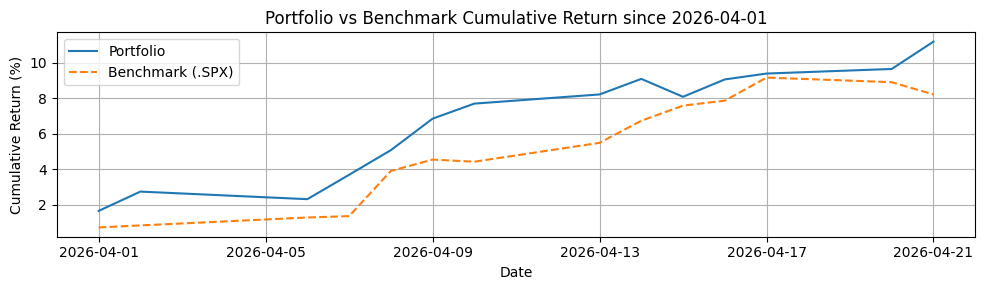

In [49]:

for index in [RUA, STOXX]:
    pos_series = scaled_positions[scaled_positions.region==index.region].set_index('internal_code').target_notional
    pos_series
    if not pos_series.empty:
        plot_portfolio_returns(pos_series, index, start_date='2026-04-01')
        new_positions = scaled_positions[scaled_positions.region == index.region]
        print(risk(pos_series))
    else:
        new_positions = pd.DataFrame(
            {'internal_code': '.STOXX50E', 'target_notional': 0.0, 'currency': 'EUR', 'region': 'EMEA', 'fx_rate': 1.0, 'usd_notional': 0.0}, index=[0]
        )
    
    send_new_portfolio(
        targets=new_positions,
        region=index.region,
        submit=False
    )
    print('beta:', portfolio_beta(pos_series, index))


positions = most_recent_positions(stock_index=RUA)
plot_portfolio_returns(positions, stock_index=RUA)
# positions = most_recent_positions(stock_index=STOXX)
# plot_portfolio_returns(positions, stock_index=STOXX)

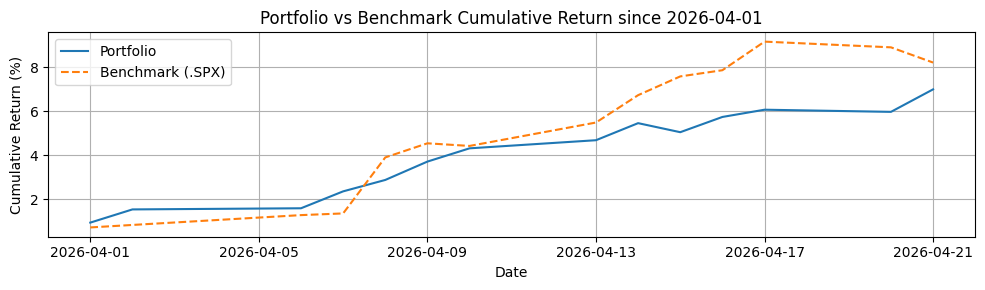

In [29]:
positions = most_recent_positions(stock_index=RUA)
plot_portfolio_returns(positions, stock_index=RUA)

### Factor Portfolio Optimisation

- Combine different strategies: mom, value, quality
- See which strategies/region combinations are currently best performing
- Determine current market inovations which would suggest changing strategy weights

## Instructions

### Hedging
To hedge excessive residual beta in your equity portfolio:
1.	Compute the beta of each stock using a 250-day covariance with its benchmark:
$$\text{Beta} = 0.2 + 0.8 \times \frac{\text{Cov}_{250d}(\text{stock}, \text{benchmark})}{\text{Var}_{250d}(\text{benchmark})}$$
2. Hedge the beta exposure by taking a position in the benchmark equal to:
$$\text{Hedge Position} = -\text{Beta}$$
3. Benchmarks:
  - AMER: S&P 500 (SPX)
  - EMEA: Eurostoxx50

This means that if a stock has a beta of 1.2, you would short 1.2 units of the benchmark to neutralize the market exposure.

### Trading Limits
There are some trading limits for single stocks: 
- Max position = 2.5% of the 60 trading days ADV 
- Max traded per day = 2.5% of the 60 trading days ADV 

For single stocks, there is also a max position in term of USD: 
- Max position = 2 M USD 

If the implied trading by targets exceeds the above limits, the position will be kept constant until all limits are not exceeded anymore. 

### Trading Costs
The execution price will be the mid-price at the end of the next minute after we have received your file (without format error) on the ftp. Additional execution costs of 2bps also apply, along with 0.5% (annually) for financing. 

100% of dividends are paid on short positions. 70% of dividends are received on long positions. 

### Ex-Ante Portfolio Risk

Risk Formula
$$
\text{Risk}_t = \sqrt{ x_t^\top \, \Sigma_t \, x_t }
$$

Where:
- $x_t$ = portfolio weights at time $t$
- $\Sigma_t$ = covariance matrix of asset returns  

Computation Steps
1. Select last 60 daily returns.  
2. Compute daily P&L:

$$
\text{PnL}_t = \text{positions}_{t-1} \cdot \text{return}_t
$$

3. Compute standard deviation of P&L.  
4. Annualise: multiply by $\sqrt{252}$.  

Simulation Parameters
- Asset class: Equities  
- Regions: AMER, EMEA  
- Universe: Russell 3000, Stoxx 600  
- Trading hours: Standard per region  
- Execution cost: 2 bps  
- Financing cost: 0.5% GMV  
- Dividend tax: 30%  
- Spread cost: 0  
- Max traded/day: 2.5% ADV  
- Position limit: 2.5% ADV  
- Auto-hedging: TRUE  
- Risk limit: 500k USD (annualised)